In [1]:
from pathlib import Path
desktop = Path.home() / "Desktop"

開始動態變分虛擬時間演化訓練
迭代 01 參數數量 03 能量 3.0159 殘差 0.0023
迭代 02 參數數量 03 能量 2.9406 殘差 0.0033
迭代 03 參數數量 03 能量 2.8325 殘差 0.0052
迭代 04 參數數量 03 能量 2.6787 殘差 0.0107
迭代 05 參數數量 03 能量 2.4635 殘差 0.0295
迭代 06 參數數量 03 能量 2.1699 殘差 0.0855
偵測到殘差過高且能量未收斂
已動態加入糾纏閘 XX
迭代 07 參數數量 04 能量 2.1699 殘差 0.0849
偵測到殘差過高且能量未收斂
已動態加入糾纏閘 YY
迭代 08 參數數量 05 能量 2.1699 殘差 0.0848
偵測到殘差過高且能量未收斂
已動態加入糾纏閘 ZZ
迭代 09 參數數量 06 能量 2.1699 殘差 0.0848
偵測到殘差過高且能量未收斂
已動態加入糾纏閘 XY
迭代 10 參數數量 07 能量 2.1699 殘差 0.0391
迭代 11 參數數量 07 能量 1.7843 殘差 0.0982
偵測到殘差過高且能量未收斂
已動態加入糾纏閘 YX
迭代 12 參數數量 08 能量 1.7843 殘差 0.0887
偵測到殘差過高且能量未收斂
已動態加入糾纏閘 XZ
迭代 13 參數數量 09 能量 1.7843 殘差 0.0887
迭代 14 參數數量 09 能量 1.3079 殘差 0.1984
迭代 15 參數數量 09 能量 0.7636 殘差 0.4052
迭代 16 參數數量 09 能量 0.1993 殘差 0.7543
迭代 17 參數數量 09 能量 -0.3236 殘差 1.3968
迭代 18 參數數量 09 能量 -0.7465 殘差 2.6616
迭代 19 參數數量 09 能量 -1.0243 殘差 4.1479
迭代 20 參數數量 09 能量 -1.1829 殘差 4.9447
迭代 21 參數數量 09 能量 -1.2762 殘差 4.9598
迭代 22 參數數量 09 能量 -1.3516 殘差 5.0857
迭代 23 參數數量 09 能量 -1.4066 殘差 4.5237
迭代 24 參數數量 09 能量 -1.4564 殘差 4.3294
迭代 25

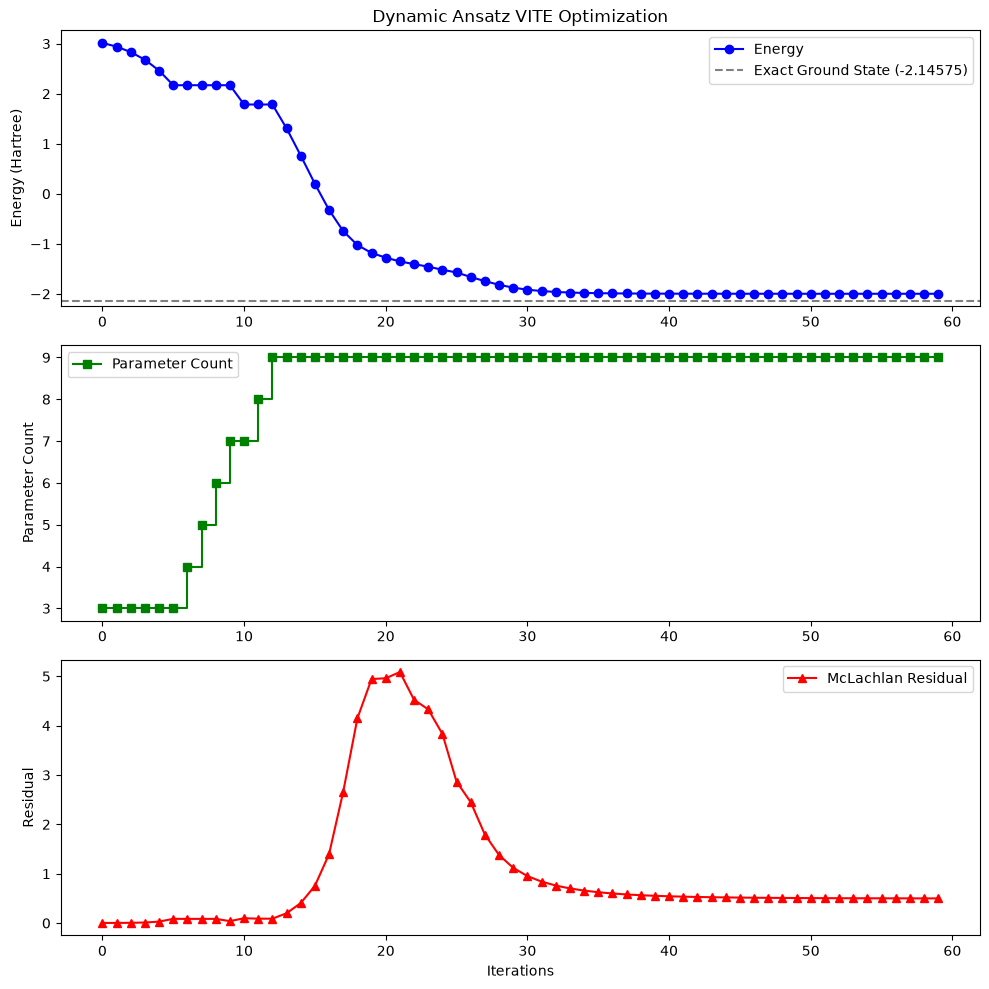

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate

# 建立哈密頓量
def ising_hamiltonian(n, J, h):
    paulis = []
    coeffs = []
    for i in range(n):
        for j in range(i+1, n):
            label = ["I"] * n
            label[i] = "Z"
            label[j] = "Z"
            paulis.append("".join(label))
            coeffs.append(J)
    for i in range(n):
        label = ["I"] * n
        label[i] = "X"
        paulis.append("".join(label))
        coeffs.append(h)
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

nqubits = 3
Hamiltonian = ising_hamiltonian(nqubits, 1, 0.5)

# 精確的量子線路與狀態模擬函數
def build_ansatz(params, ops_list):
    qc = QuantumCircuit(nqubits)
    for op_str, param in zip(ops_list, params):
        op = SparsePauliOp(op_str)
        if len(op_str) == 1:
            for q in range(nqubits):
                qc.append(PauliEvolutionGate(op, time=param), [q])
        else:
            for q in range(nqubits - 1):
                qc.append(PauliEvolutionGate(op, time=param), [q, q+1])
    return qc

def get_energy(params, ops_list, H):
    qc = build_ansatz(params, ops_list)
    sv = Statevector(qc)
    return np.real(sv.expectation_value(H))

def get_V(params, ops_list, H, epsilon=1e-5):
    V = np.zeros(len(params))
    for i in range(len(params)):
        p_plus = np.copy(params)
        p_plus[i] += epsilon
        p_minus = np.copy(params)
        p_minus[i] -= epsilon
        V[i] = -(get_energy(p_plus, ops_list, H) - get_energy(p_minus, ops_list, H)) / (2 * epsilon)
    return V

def get_M(params, ops_list, epsilon=1e-5):
    sv_center = Statevector(build_ansatz(params, ops_list)).data
    derivatives = []
    for i in range(len(params)):
        p_plus = np.copy(params)
        p_plus[i] += epsilon
        p_minus = np.copy(params)
        p_minus[i] -= epsilon
        d_sv = (Statevector(build_ansatz(p_plus, ops_list)).data - Statevector(build_ansatz(p_minus, ops_list)).data) / (2 * epsilon)
        derivatives.append(d_sv)
        
    num_p = len(params)
    M = np.zeros((num_p, num_p))
    for i in range(num_p):
        for j in range(num_p):
            term1 = np.vdot(derivatives[i], derivatives[j])
            term2 = np.vdot(derivatives[i], sv_center) * np.vdot(sv_center, derivatives[j])
            M[i, j] = 2 * np.real(term1 + term2)
    return M

def get_residual(params, ops_list, H, M, V):
    e_val = get_energy(params, ops_list, H)
    H_sq = H.compose(H).simplify()
    e_sq_val = get_energy(params, ops_list, H_sq)
    var_H = e_sq_val - e_val**2
    
    M_reg = M + 0.01 * np.eye(len(params))
    M_inv = np.linalg.pinv(M_reg)
    residual = 2 * var_H - V.T @ M_inv @ V
    return residual

# 動態生長訓練迴圈
def dynamic_vite_training(H, exact_energy, max_iters=60, learning_rate=0.05, threshold=0.05):
    CANDIDATE_OPS = ["XX", "YY", "ZZ", "XY", "YX", "XZ"]
    Ops = ["X", "Y", "Z"]
    current_params = np.random.uniform(-0.01, 0.01, len(Ops))
    
    energy_history = []
    depth_history = []
    residual_history = []
    
    print("開始動態變分虛擬時間演化訓練")
    
    for iteration in range(max_iters):
        M = get_M(current_params, Ops)
        V = get_V(current_params, Ops, H)
        
        M_reg = M + 0.01 * np.eye(len(Ops))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_energy = get_energy(current_params, Ops, H)
        residual = get_residual(current_params, Ops, H, M, V)
        
        energy_history.append(current_energy)
        depth_history.append(len(Ops))
        residual_history.append(residual)
        
        print(f"迭代 {iteration+1:02d} 參數數量 {len(Ops):02d} 能量 {current_energy:.4f} 殘差 {residual:.4f}")
        
        if residual > threshold and len(CANDIDATE_OPS) > 0 and (current_energy - exact_energy) > 0.05:
            print("偵測到殘差過高且能量未收斂")
            new_op = CANDIDATE_OPS.pop(0)
            Ops.append(new_op)
            current_params = np.append(current_params, 0.0)
            print(f"已動態加入糾纏閘 {new_op}")
        else:
            current_params = current_params + learning_rate * d_theta
            
    return current_params, energy_history, depth_history, residual_history

# 執行與繪圖
exact_ground_energy = -2.14575
final_params, energies, depths, residuals = dynamic_vite_training(Hamiltonian, exact_ground_energy)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

ax1.plot(energies, marker='o', label='Energy', color='blue')
ax1.axhline(y=exact_ground_energy, color='gray', linestyle='--', label='Exact Ground State (-2.14575)')
ax1.set_ylabel('Energy (Hartree)')
ax1.set_title('Dynamic Ansatz VITE Optimization')
ax1.legend()

ax2.plot(depths, marker='s', label='Parameter Count', color='green', drawstyle='steps-post')
ax2.set_ylabel('Parameter Count')
ax2.legend()

ax3.plot(residuals, marker='^', label='McLachlan Residual', color='red')
ax3.set_ylabel('Residual')
ax3.set_xlabel('Iterations')
ax3.legend()

plt.tight_layout()
fig.savefig(desktop/'vite_simulation.svg', bbox_inches='tight')
plt.show()

開始靜態梯度下降 (GD) 訓練
開始靜態變分虛擬時間演化 (Static VITE) 訓練


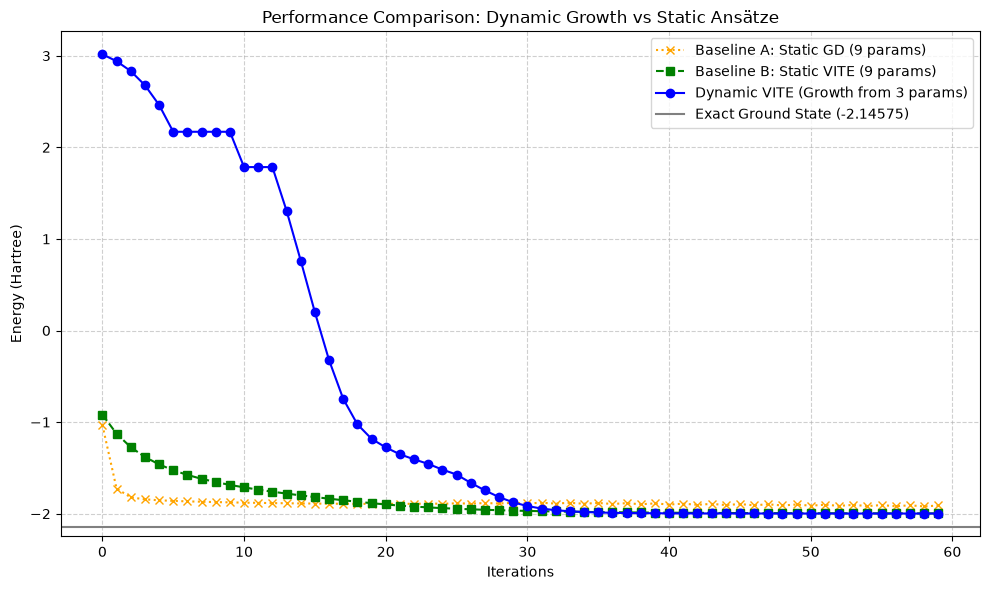

In [6]:
# 固定深度的深層擬設算符
FIXED_OPS = ["X", "Y", "Z", "XX", "YY", "ZZ", "XY", "YX", "XZ"]

def static_gd_training(H, exact_energy, max_iters=60, learning_rate=0.05):
    current_params = np.random.uniform(-0.5, 0.5, len(FIXED_OPS))
    energy_history = []
    
    print("開始靜態梯度下降 (GD) 訓練")
    for iteration in range(max_iters):
        # V 向量本質上就是負梯度方向
        V = get_V(current_params, FIXED_OPS, H)
        current_params = current_params + learning_rate * V
        
        current_energy = get_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
        
    return energy_history

def static_vite_training(H, exact_energy, max_iters=60, learning_rate=0.05):
    current_params = np.random.uniform(-0.5, 0.5, len(FIXED_OPS))
    energy_history = []
    
    print("開始靜態變分虛擬時間演化 (Static VITE) 訓練")
    for iteration in range(max_iters):
        M = get_M(current_params, FIXED_OPS)
        V = get_V(current_params, FIXED_OPS, H)
        
        M_reg = M + 0.01 * np.eye(len(FIXED_OPS))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_params = current_params + learning_rate * d_theta
        
        current_energy = get_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
        
    return energy_history

# 執行對照組實驗
gd_energies = static_gd_training(Hamiltonian, exact_ground_energy)
static_vite_energies = static_vite_training(Hamiltonian, exact_ground_energy)

# 繪製綜合比較圖表
plt.figure(figsize=(10, 6))

plt.plot(gd_energies, marker='x', linestyle=':', color='orange', label='Baseline A: Static GD (9 params)')
plt.plot(static_vite_energies, marker='s', linestyle='--', color='green', label='Baseline B: Static VITE (9 params)')
plt.plot(energies, marker='o', linestyle='-', color='blue', label='Dynamic VITE (Growth from 3 params)')

plt.axhline(y=exact_ground_energy, color='gray', linestyle='-', label='Exact Ground State (-2.14575)')

plt.ylabel('Energy (Hartree)')
plt.xlabel('Iterations')
plt.title('Performance Comparison: Dynamic Growth vs Static Ansätze')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig(desktop/'vite_simulation_1.svg', bbox_inches='tight')
plt.show()

系統規模: 6 Qubits
相變臨界點精確基態能量: -7.3478 Hartree

開始執行對照組 A：靜態梯度下降 (9 Params)
開始執行對照組 B：靜態 VITE (9 Params)
開始執行實驗組：動態生長 VITE (From 3 Params)
  [Iter 03] 殘差過高 (0.1148)，已動態加入量子閘: XX
  [Iter 04] 殘差過高 (0.1142)，已動態加入量子閘: YY
  [Iter 05] 殘差過高 (0.1142)，已動態加入量子閘: ZZ
  [Iter 06] 殘差過高 (0.1141)，已動態加入量子閘: XY
  [Iter 07] 殘差過高 (0.0912)，已動態加入量子閘: YX
  [Iter 08] 殘差過高 (0.0911)，已動態加入量子閘: XZ
  [Iter 09] 殘差過高 (0.0911)，已動態加入量子閘: ZX
  [Iter 10] 殘差過高 (0.0910)，已動態加入量子閘: YZ
  [Iter 11] 殘差過高 (0.0903)，已動態加入量子閘: ZY
動態 VITE 最終參數數量: 12



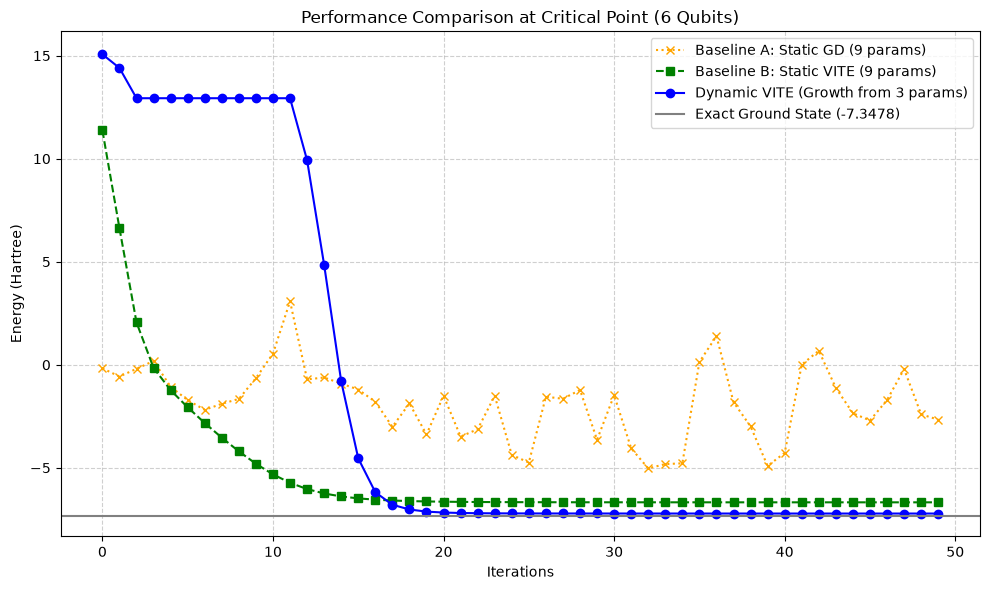

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate

# ==========================================
# 1. 系統規模與物理參數設定 (橫向場伊辛模型)
# ==========================================
nqubits = 6  # 測試擴展性，可修改為 8
J_coupling = 1.0
h_field = 1.0

def ising_hamiltonian(n, J, h):
    paulis = []
    coeffs = []
    # ZZ 交互作用
    for i in range(n):
        for j in range(i+1, n):
            label = ["I"] * n
            label[i] = "Z"
            label[j] = "Z"
            paulis.append("".join(label))
            coeffs.append(J)
    # X 方向橫向磁場
    for i in range(n):
        label = ["I"] * n
        label[i] = "X"
        paulis.append("".join(label))
        coeffs.append(h)
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

Hamiltonian = ising_hamiltonian(nqubits, J_coupling, h_field)

# 自動對角化計算任意 N 量子位元系統的精確基態能量
H_matrix = Hamiltonian.to_matrix()
eigenvalues = eigh(H_matrix, eigvals_only=True)
exact_ground_energy = eigenvalues[0]

print(f"系統規模: {nqubits} Qubits")
print(f"相變臨界點精確基態能量: {exact_ground_energy:.4f} Hartree\n")

# ==========================================
# 2. 精確的狀態向量模擬底層函數 (消除 Shot Noise)
# ==========================================
def build_ansatz(params, ops_list):
    """建立參數共享的硬體效率擬設"""
    qc = QuantumCircuit(nqubits)
    for op_str, param in zip(ops_list, params):
        op = SparsePauliOp(op_str)
        if len(op_str) == 1:
            for q in range(nqubits):
                qc.append(PauliEvolutionGate(op, time=param), [q])
        else:
            for q in range(nqubits - 1):
                qc.append(PauliEvolutionGate(op, time=param), [q, q+1])
    return qc

def get_energy(params, ops_list, H):
    qc = build_ansatz(params, ops_list)
    sv = Statevector(qc)
    return np.real(sv.expectation_value(H))

def get_V(params, ops_list, H, epsilon=1e-5):
    """利用數值微分取得 V 向量 (負梯度)"""
    V = np.zeros(len(params))
    for i in range(len(params)):
        p_plus = np.copy(params)
        p_plus[i] += epsilon
        p_minus = np.copy(params)
        p_minus[i] -= epsilon
        V[i] = -(get_energy(p_plus, ops_list, H) - get_energy(p_minus, ops_list, H)) / (2 * epsilon)
    return V

def get_M(params, ops_list, epsilon=1e-5):
    """取得 M 矩陣 (A矩陣)"""
    sv_center = Statevector(build_ansatz(params, ops_list)).data
    derivatives = []
    for i in range(len(params)):
        p_plus = np.copy(params)
        p_plus[i] += epsilon
        p_minus = np.copy(params)
        p_minus[i] -= epsilon
        d_sv = (Statevector(build_ansatz(p_plus, ops_list)).data - Statevector(build_ansatz(p_minus, ops_list)).data) / (2 * epsilon)
        derivatives.append(d_sv)
        
    num_p = len(params)
    M = np.zeros((num_p, num_p))
    for i in range(num_p):
        for j in range(num_p):
            term1 = np.vdot(derivatives[i], derivatives[j])
            term2 = np.vdot(derivatives[i], sv_center) * np.vdot(sv_center, derivatives[j])
            M[i, j] = 2 * np.real(term1 + term2)
    return M

def get_residual(params, ops_list, H, M, V):
    """計算 McLachlan 殘差平方"""
    e_val = get_energy(params, ops_list, H)
    H_sq = (H @ H).simplify()
    e_sq_val = get_energy(params, ops_list, H_sq)
    var_H = e_sq_val - e_val**2
    
    # 加入正規化項確保反轉穩定
    M_reg = M + 0.01 * np.eye(len(params))
    M_inv = np.linalg.pinv(M_reg)
    residual = 2 * var_H - V.T @ M_inv @ V
    return residual

# ==========================================
# 3. 訓練演算法模組 (對照組與動態組)
# ==========================================
FIXED_OPS = ["X", "Y", "Z", "XX", "YY", "ZZ", "XY", "YX", "XZ"]

def static_gd_training(H, max_iters=50, learning_rate=0.05):
    """對照組 A：靜態梯度下降法"""
    current_params = np.random.uniform(-0.1, 0.1, len(FIXED_OPS))
    energy_history = []
    
    print("開始執行對照組 A：靜態梯度下降 (9 Params)")
    for iteration in range(max_iters):
        V = get_V(current_params, FIXED_OPS, H)
        current_params = current_params + learning_rate * V
        current_energy = get_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
    return energy_history

def static_vite_training(H, max_iters=50, learning_rate=0.05):
    """對照組 B：靜態變分虛擬時間演化"""
    current_params = np.random.uniform(-0.1, 0.1, len(FIXED_OPS))
    energy_history = []
    
    print("開始執行對照組 B：靜態 VITE (9 Params)")
    for iteration in range(max_iters):
        M = get_M(current_params, FIXED_OPS)
        V = get_V(current_params, FIXED_OPS, H)
        
        M_reg = M + 0.01 * np.eye(len(FIXED_OPS))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_params = current_params + learning_rate * d_theta
        current_energy = get_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
    return energy_history

def dynamic_vite_training(H, exact_energy, max_iters=50, learning_rate=0.05, threshold=0.05):
    """實驗組：動態生長 VITE"""
    CANDIDATE_OPS = ["XX", "YY", "ZZ", "XY", "YX", "XZ", "ZX", "YZ", "ZY"]
    Ops = ["X", "Y", "Z"]
    current_params = np.random.uniform(-0.01, 0.01, len(Ops))
    
    energy_history = []
    
    print("開始執行實驗組：動態生長 VITE (From 3 Params)")
    for iteration in range(max_iters):
        M = get_M(current_params, Ops)
        V = get_V(current_params, Ops, H)
        
        M_reg = M + 0.01 * np.eye(len(Ops))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_energy = get_energy(current_params, Ops, H)
        residual = get_residual(current_params, Ops, H, M, V)
        energy_history.append(current_energy)
        
        # 殘差觸發機制
        if residual > threshold and len(CANDIDATE_OPS) > 0 and (current_energy - exact_energy) > 0.05:
            new_op = CANDIDATE_OPS.pop(0)
            Ops.append(new_op)
            current_params = np.append(current_params, 0.0)
            print(f"  [Iter {iteration+1:02d}] 殘差過高 ({residual:.4f})，已動態加入量子閘: {new_op}")
        else:
            current_params = current_params + learning_rate * d_theta
            
    print(f"動態 VITE 最終參數數量: {len(Ops)}\n")
    return energy_history

# ==========================================
# 4. 執行實驗與繪製綜合比較圖表
# ==========================================
iters = 50
gd_energies = static_gd_training(Hamiltonian, max_iters=iters)
svite_energies = static_vite_training(Hamiltonian, max_iters=iters)
dvite_energies = dynamic_vite_training(Hamiltonian, exact_ground_energy, max_iters=iters)

plt.figure(figsize=(10, 6))

plt.plot(gd_energies, marker='x', linestyle=':', color='orange', label='Baseline A: Static GD (9 params)')
plt.plot(svite_energies, marker='s', linestyle='--', color='green', label='Baseline B: Static VITE (9 params)')
plt.plot(dvite_energies, marker='o', linestyle='-', color='blue', label='Dynamic VITE (Growth from 3 params)')

plt.axhline(y=exact_ground_energy, color='gray', linestyle='-', label=f'Exact Ground State ({exact_ground_energy:.4f})')

plt.ylabel('Energy (Hartree)')
plt.xlabel('Iterations')
plt.title(f'Performance Comparison at Critical Point ({nqubits} Qubits)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig(desktop/'vite_simulation_2.svg', bbox_inches='tight')
plt.show()

系統規模: 8 Qubits
相變臨界點精確基態能量: -10.0040 Hartree

開始執行對照組 A：靜態梯度下降 (9 Params)
開始執行對照組 B：靜態 VITE (9 Params)
開始執行實驗組：動態生長 VITE (From 3 Params)
  [Iter 03] 殘差過高 (0.1897)，已動態加入量子閘: XX
  [Iter 04] 殘差過高 (0.1897)，已動態加入量子閘: YY
  [Iter 05] 殘差過高 (0.1897)，已動態加入量子閘: ZZ
  [Iter 06] 殘差過高 (0.1897)，已動態加入量子閘: XY
  [Iter 07] 殘差過高 (0.1582)，已動態加入量子閘: YX
  [Iter 08] 殘差過高 (0.1581)，已動態加入量子閘: XZ
  [Iter 09] 殘差過高 (0.1581)，已動態加入量子閘: ZX
  [Iter 10] 殘差過高 (0.1581)，已動態加入量子閘: YZ
  [Iter 11] 殘差過高 (0.1570)，已動態加入量子閘: ZY
動態 VITE 最終參數數量: 12



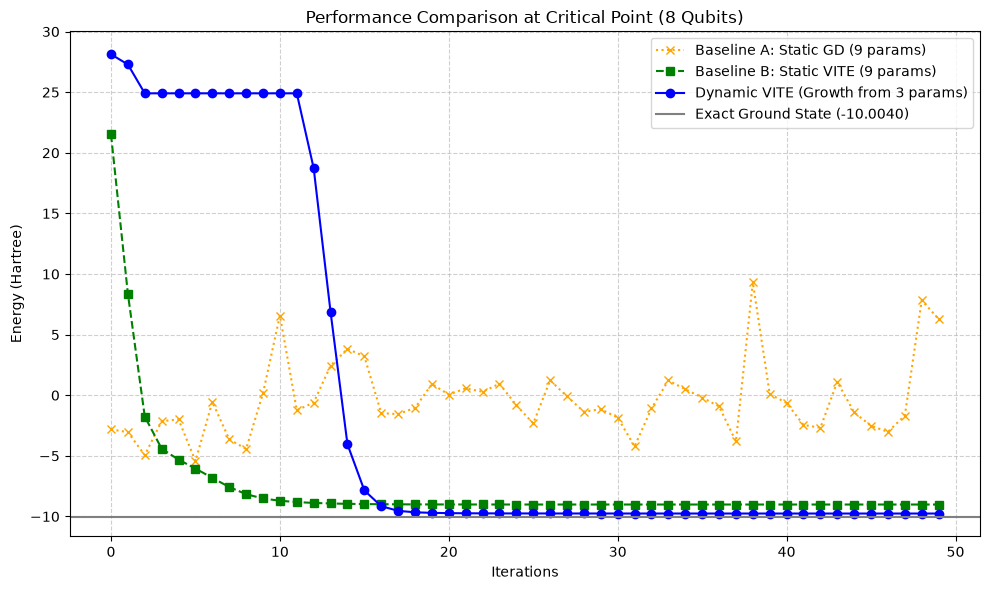

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate

# ==========================================
# 1. 系統規模與物理參數設定 (橫向場伊辛模型)
# ==========================================
nqubits = 8  # 測試擴展性，可修改為 8
J_coupling = 1.0
h_field = 1.0

def ising_hamiltonian(n, J, h):
    paulis = []
    coeffs = []
    # ZZ 交互作用
    for i in range(n):
        for j in range(i+1, n):
            label = ["I"] * n
            label[i] = "Z"
            label[j] = "Z"
            paulis.append("".join(label))
            coeffs.append(J)
    # X 方向橫向磁場
    for i in range(n):
        label = ["I"] * n
        label[i] = "X"
        paulis.append("".join(label))
        coeffs.append(h)
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

Hamiltonian = ising_hamiltonian(nqubits, J_coupling, h_field)

# 自動對角化計算任意 N 量子位元系統的精確基態能量
H_matrix = Hamiltonian.to_matrix()
eigenvalues = eigh(H_matrix, eigvals_only=True)
exact_ground_energy = eigenvalues[0]

print(f"系統規模: {nqubits} Qubits")
print(f"相變臨界點精確基態能量: {exact_ground_energy:.4f} Hartree\n")

# ==========================================
# 2. 精確的狀態向量模擬底層函數 (消除 Shot Noise)
# ==========================================
def build_ansatz(params, ops_list):
    """建立參數共享的硬體效率擬設"""
    qc = QuantumCircuit(nqubits)
    for op_str, param in zip(ops_list, params):
        op = SparsePauliOp(op_str)
        if len(op_str) == 1:
            for q in range(nqubits):
                qc.append(PauliEvolutionGate(op, time=param), [q])
        else:
            for q in range(nqubits - 1):
                qc.append(PauliEvolutionGate(op, time=param), [q, q+1])
    return qc

def get_energy(params, ops_list, H):
    qc = build_ansatz(params, ops_list)
    sv = Statevector(qc)
    return np.real(sv.expectation_value(H))

def get_V(params, ops_list, H, epsilon=1e-5):
    """利用數值微分取得 V 向量 (負梯度)"""
    V = np.zeros(len(params))
    for i in range(len(params)):
        p_plus = np.copy(params)
        p_plus[i] += epsilon
        p_minus = np.copy(params)
        p_minus[i] -= epsilon
        V[i] = -(get_energy(p_plus, ops_list, H) - get_energy(p_minus, ops_list, H)) / (2 * epsilon)
    return V

def get_M(params, ops_list, epsilon=1e-5):
    """取得 M 矩陣 (A矩陣)"""
    sv_center = Statevector(build_ansatz(params, ops_list)).data
    derivatives = []
    for i in range(len(params)):
        p_plus = np.copy(params)
        p_plus[i] += epsilon
        p_minus = np.copy(params)
        p_minus[i] -= epsilon
        d_sv = (Statevector(build_ansatz(p_plus, ops_list)).data - Statevector(build_ansatz(p_minus, ops_list)).data) / (2 * epsilon)
        derivatives.append(d_sv)
        
    num_p = len(params)
    M = np.zeros((num_p, num_p))
    for i in range(num_p):
        for j in range(num_p):
            term1 = np.vdot(derivatives[i], derivatives[j])
            term2 = np.vdot(derivatives[i], sv_center) * np.vdot(sv_center, derivatives[j])
            M[i, j] = 2 * np.real(term1 + term2)
    return M

def get_residual(params, ops_list, H, M, V):
    """計算 McLachlan 殘差平方"""
    e_val = get_energy(params, ops_list, H)
    H_sq = (H @ H).simplify()
    e_sq_val = get_energy(params, ops_list, H_sq)
    var_H = e_sq_val - e_val**2
    
    # 加入正規化項確保反轉穩定
    M_reg = M + 0.01 * np.eye(len(params))
    M_inv = np.linalg.pinv(M_reg)
    residual = 2 * var_H - V.T @ M_inv @ V
    return residual

# ==========================================
# 3. 訓練演算法模組 (對照組與動態組)
# ==========================================
FIXED_OPS = ["X", "Y", "Z", "XX", "YY", "ZZ", "XY", "YX", "XZ"]

def static_gd_training(H, max_iters=50, learning_rate=0.05):
    """對照組 A：靜態梯度下降法"""
    current_params = np.random.uniform(-0.1, 0.1, len(FIXED_OPS))
    energy_history = []
    
    print("開始執行對照組 A：靜態梯度下降 (9 Params)")
    for iteration in range(max_iters):
        V = get_V(current_params, FIXED_OPS, H)
        current_params = current_params + learning_rate * V
        current_energy = get_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
    return energy_history

def static_vite_training(H, max_iters=50, learning_rate=0.05):
    """對照組 B：靜態變分虛擬時間演化"""
    current_params = np.random.uniform(-0.1, 0.1, len(FIXED_OPS))
    energy_history = []
    
    print("開始執行對照組 B：靜態 VITE (9 Params)")
    for iteration in range(max_iters):
        M = get_M(current_params, FIXED_OPS)
        V = get_V(current_params, FIXED_OPS, H)
        
        M_reg = M + 0.01 * np.eye(len(FIXED_OPS))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_params = current_params + learning_rate * d_theta
        current_energy = get_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
    return energy_history

def dynamic_vite_training(H, exact_energy, max_iters=50, learning_rate=0.05, threshold=0.05):
    """實驗組：動態生長 VITE"""
    CANDIDATE_OPS = ["XX", "YY", "ZZ", "XY", "YX", "XZ", "ZX", "YZ", "ZY"]
    Ops = ["X", "Y", "Z"]
    current_params = np.random.uniform(-0.01, 0.01, len(Ops))
    
    energy_history = []
    
    print("開始執行實驗組：動態生長 VITE (From 3 Params)")
    for iteration in range(max_iters):
        M = get_M(current_params, Ops)
        V = get_V(current_params, Ops, H)
        
        M_reg = M + 0.01 * np.eye(len(Ops))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_energy = get_energy(current_params, Ops, H)
        residual = get_residual(current_params, Ops, H, M, V)
        energy_history.append(current_energy)
        
        # 殘差觸發機制
        if residual > threshold and len(CANDIDATE_OPS) > 0 and (current_energy - exact_energy) > 0.05:
            new_op = CANDIDATE_OPS.pop(0)
            Ops.append(new_op)
            current_params = np.append(current_params, 0.0)
            print(f"  [Iter {iteration+1:02d}] 殘差過高 ({residual:.4f})，已動態加入量子閘: {new_op}")
        else:
            current_params = current_params + learning_rate * d_theta
            
    print(f"動態 VITE 最終參數數量: {len(Ops)}\n")
    return energy_history

# ==========================================
# 4. 執行實驗與繪製綜合比較圖表
# ==========================================
iters = 50
gd_energies = static_gd_training(Hamiltonian, max_iters=iters)
svite_energies = static_vite_training(Hamiltonian, max_iters=iters)
dvite_energies = dynamic_vite_training(Hamiltonian, exact_ground_energy, max_iters=iters)

plt.figure(figsize=(10, 6))

plt.plot(gd_energies, marker='x', linestyle=':', color='orange', label='Baseline A: Static GD (9 params)')
plt.plot(svite_energies, marker='s', linestyle='--', color='green', label='Baseline B: Static VITE (9 params)')
plt.plot(dvite_energies, marker='o', linestyle='-', color='blue', label='Dynamic VITE (Growth from 3 params)')

plt.axhline(y=exact_ground_energy, color='gray', linestyle='-', label=f'Exact Ground State ({exact_ground_energy:.4f})')

plt.ylabel('Energy (Hartree)')
plt.xlabel('Iterations')
plt.title(f'Performance Comparison at Critical Point ({nqubits} Qubits)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig(desktop/'vite_simulation_3.svg', bbox_inches='tight')
plt.show()

系統規模: 6 Qubits
精確基態能量: -7.3478 Hartree

啟動含噪去極化壓力測試 (Depolarizing Noise Active)
Iter: 01 | 參數: 03 | 雜訊能量: 14.9970 | 殘差: 6.9682
  >>> 雜訊擾動下觸發動態生長: 加入 XX


/Users/yuhaochen/Documents/env/qiskit/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yuhaochen/Documents/env/qiskit/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Iter: 02 | 參數: 04 | 雜訊能量: 13.8999 | 殘差: 32.3106
  >>> 雜訊擾動下觸發動態生長: 加入 YY
Iter: 03 | 參數: 05 | 雜訊能量: 12.9673 | 殘差: 50.9848
  >>> 雜訊擾動下觸發動態生長: 加入 ZZ
Iter: 04 | 參數: 06 | 雜訊能量: 12.1959 | 殘差: 64.5673
  >>> 雜訊擾動下觸發動態生長: 加入 XY
Iter: 05 | 參數: 07 | 雜訊能量: 11.3447 | 殘差: 76.8946
  >>> 雜訊擾動下觸發動態生長: 加入 YX
Iter: 06 | 參數: 08 | 雜訊能量: 10.5589 | 殘差: 86.4250
  >>> 雜訊擾動下觸發動態生長: 加入 XZ
Iter: 07 | 參數: 09 | 雜訊能量: 9.8714 | 殘差: 93.1021
Iter: 08 | 參數: 09 | 雜訊能量: 9.7675 | 殘差: 93.5588
Iter: 09 | 參數: 09 | 雜訊能量: 9.6425 | 殘差: 94.0297
Iter: 10 | 參數: 09 | 雜訊能量: 9.4925 | 殘差: 94.5089
Iter: 11 | 參數: 09 | 雜訊能量: 9.3128 | 殘差: 94.9914
Iter: 12 | 參數: 09 | 雜訊能量: 9.0982 | 殘差: 95.4552
Iter: 13 | 參數: 09 | 雜訊能量: 8.8428 | 殘差: 95.8709
Iter: 14 | 參數: 09 | 雜訊能量: 8.5407 | 殘差: 96.2022
Iter: 15 | 參數: 09 | 雜訊能量: 8.1862 | 殘差: 96.4041
Iter: 16 | 參數: 09 | 雜訊能量: 7.7741 | 殘差: 96.4262
Iter: 17 | 參數: 09 | 雜訊能量: 7.3007 | 殘差: 96.2228
Iter: 18 | 參數: 09 | 雜訊能量: 6.7649 | 殘差: 95.7690
Iter: 19 | 參數: 09 | 雜訊能量: 6.1689 | 殘差: 95.0711
Iter: 20 | 參數: 09 | 雜訊能量

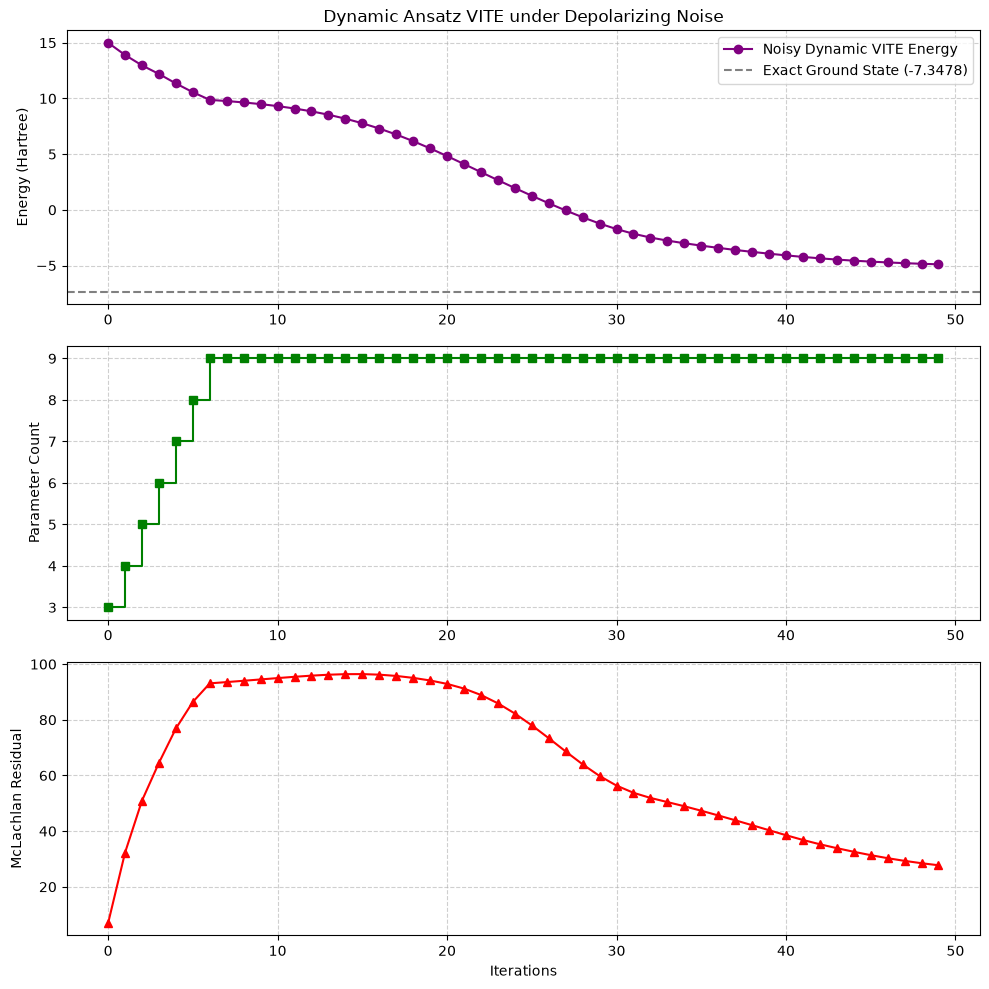

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, DensityMatrix
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# ==========================================
# 1. 系統與雜訊模型設定
# ==========================================
nqubits = 6  
J_coupling = 1.0
h_field = 1.0

# 建立去極化雜訊模型
noise_model = NoiseModel()
# 設定符合當前 NISQ 設備水準的錯誤率
error_1q = depolarizing_error(0.001, 1)  # 0.1% 單量子位元錯誤
error_2q = depolarizing_error(0.01, 2)   # 1.0% 雙量子位元錯誤
noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'ry', 'rz'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

# 使用密度矩陣模擬器以獲取精確的含噪期望值 (消除 Shot Noise 變異)
noisy_sim = AerSimulator(method='density_matrix', noise_model=noise_model)

def ising_hamiltonian(n, J, h):
    paulis, coeffs = [], []
    for i in range(n):
        for j in range(i+1, n):
            label = ["I"] * n
            label[i], label[j] = "Z", "Z"
            paulis.append("".join(label))
            coeffs.append(J)
    for i in range(n):
        label = ["I"] * n
        label[i] = "X"
        paulis.append("".join(label))
        coeffs.append(h)
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

Hamiltonian = ising_hamiltonian(nqubits, J_coupling, h_field)
exact_ground_energy = eigh(Hamiltonian.to_matrix(), eigvals_only=True)[0]

print(f"系統規模: {nqubits} Qubits")
print(f"精確基態能量: {exact_ground_energy:.4f} Hartree\n")

# ==========================================
# 2. 含噪測量底層函數
# ==========================================
def build_ansatz(params, ops_list):
    qc = QuantumCircuit(nqubits)
    for op_str, param in zip(ops_list, params):
        op = SparsePauliOp(op_str)
        if len(op_str) == 1:
            for q in range(nqubits):
                qc.append(PauliEvolutionGate(op, time=param), [q])
        else:
            for q in range(nqubits - 1):
                qc.append(PauliEvolutionGate(op, time=param), [q, q+1])
    return qc

def get_noisy_energy(params, ops_list, H):
    qc = build_ansatz(params, ops_list)
    # 將 PauliEvolution 展開為基礎閘以套用雜訊模型
    qc_t = transpile(qc, basis_gates=['rx', 'ry', 'rz', 'cx'], optimization_level=0)
    qc_t.save_density_matrix()
    
    result = noisy_sim.run(qc_t).result()
    rho = result.data()['density_matrix']
    # 追跡計算含噪能量
    return np.real(np.trace(rho.data @ H.to_matrix()))

def get_noisy_V(params, ops_list, H, epsilon=1e-4):
    V = np.zeros(len(params))
    for i in range(len(params)):
        p_plus, p_minus = np.copy(params), np.copy(params)
        p_plus[i] += epsilon
        p_minus[i] -= epsilon
        V[i] = -(get_noisy_energy(p_plus, ops_list, H) - get_noisy_energy(p_minus, ops_list, H)) / (2 * epsilon)
    return V

# 為了確保 M 矩陣的半正定與反轉穩定性，此處保留理想度量張量，但驅動的 V 與殘差引入真實雜訊
def get_M_ideal(params, ops_list, epsilon=1e-4):
    sv_center = DensityMatrix(build_ansatz(params, ops_list)).data
    derivatives = []
    for i in range(len(params)):
        p_plus, p_minus = np.copy(params), np.copy(params)
        p_plus[i] += epsilon
        p_minus[i] -= epsilon
        rho_plus = DensityMatrix(build_ansatz(p_plus, ops_list)).data
        rho_minus = DensityMatrix(build_ansatz(p_minus, ops_list)).data
        derivatives.append((rho_plus - rho_minus) / (2 * epsilon))
        
    num_p = len(params)
    M = np.zeros((num_p, num_p))
    for i in range(num_p):
        for j in range(num_p):
            term1 = np.trace(derivatives[i] @ derivatives[j])
            term2 = np.trace(derivatives[i] @ sv_center) * np.trace(sv_center @ derivatives[j])
            M[i, j] = 2 * np.real(term1 + term2)
    return M

def get_noisy_residual(params, ops_list, H, M, V):
    e_val = get_noisy_energy(params, ops_list, H)
    H_sq = (H @ H).simplify()
    e_sq_val = get_noisy_energy(params, ops_list, H_sq)
    # 雜訊會使變異數膨脹
    var_H = e_sq_val - e_val**2 
    
    M_reg = M + 0.05 * np.eye(len(params))  # 提高正規化係數以對抗雜訊
    M_inv = np.linalg.pinv(M_reg)
    residual = 2 * var_H - V.T @ M_inv @ V
    return residual

# ==========================================
# 3. 壓力測試訓練迴圈
# ==========================================
def dynamic_vite_noisy_stress_test(H, exact_energy, max_iters=50, learning_rate=0.03, threshold=0.2):
    CANDIDATE_OPS = ["XX", "YY", "ZZ", "XY", "YX", "XZ"]
    Ops = ["X", "Y", "Z"]
    current_params = np.random.uniform(-0.01, 0.01, len(Ops))
    
    energy_history, depth_history, residual_history = [], [], []
    
    print("啟動含噪去極化壓力測試 (Depolarizing Noise Active)")
    for iteration in range(max_iters):
        M = get_M_ideal(current_params, Ops)
        V = get_noisy_V(current_params, Ops, H)
        
        M_reg = M + 0.05 * np.eye(len(Ops))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_energy = get_noisy_energy(current_params, Ops, H)
        residual = get_noisy_residual(current_params, Ops, H, M, V)
        
        energy_history.append(current_energy)
        depth_history.append(len(Ops))
        residual_history.append(residual)
        
        print(f"Iter: {iteration+1:02d} | 參數: {len(Ops):02d} | 雜訊能量: {current_energy:.4f} | 殘差: {residual:.4f}")
        
        # 雜訊環境下的觸發條件：殘差較大且未達雜訊極限
        if residual > threshold and len(CANDIDATE_OPS) > 0 and (current_energy - exact_energy) > 0.15:
            new_op = CANDIDATE_OPS.pop(0)
            Ops.append(new_op)
            current_params = np.append(current_params, 0.0)
            print(f"  >>> 雜訊擾動下觸發動態生長: 加入 {new_op}")
        else:
            current_params = current_params + learning_rate * d_theta
            
    return energy_history, depth_history, residual_history

noisy_energies, noisy_depths, noisy_residuals = dynamic_vite_noisy_stress_test(Hamiltonian, exact_ground_energy)

# ==========================================
# 4. 繪圖輸出
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

ax1.plot(noisy_energies, marker='o', color='purple', label='Noisy Dynamic VITE Energy')
ax1.axhline(y=exact_ground_energy, color='gray', linestyle='--', label=f'Exact Ground State ({exact_ground_energy:.4f})')
ax1.set_ylabel('Energy (Hartree)')
ax1.set_title('Dynamic Ansatz VITE under Depolarizing Noise')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.plot(noisy_depths, marker='s', color='green', drawstyle='steps-post')
ax2.set_ylabel('Parameter Count')
ax2.grid(True, linestyle='--', alpha=0.6)

ax3.plot(noisy_residuals, marker='^', color='red')
ax3.set_ylabel('McLachlan Residual')
ax3.set_xlabel('Iterations')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig.savefig(desktop/'vite_simulation_4.svg', bbox_inches='tight')
plt.show()

System Size: 10 Qubits
Exact Ground Energy: -12.6956 Hartree

Run Noisy Static GD
Run Noisy Static VITE


/Users/yuhaochen/Documents/env/qiskit/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yuhaochen/Documents/env/qiskit/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


開始執行實驗組：含噪動態生長 VITE (From 3 Params)
  [Iter 01] 參數: 03 | 能量: 44.7353 | 殘差: 19.6291
    >>> 觸發動態生長: 已加入量子閘 XX
  [Iter 02] 參數: 04 | 能量: 40.7369 | 殘差: 183.2953
    >>> 觸發動態生長: 已加入量子閘 YY
  [Iter 03] 參數: 05 | 能量: 37.1916 | 殘差: 299.5465
    >>> 觸發動態生長: 已加入量子閘 ZZ
  [Iter 04] 參數: 06 | 能量: 34.0444 | 殘差: 380.3201
    >>> 觸發動態生長: 已加入量子閘 XY
  [Iter 05] 參數: 07 | 能量: 30.5057 | 殘差: 444.8705
    >>> 觸發動態生長: 已加入量子閘 YX
  [Iter 06] 參數: 08 | 能量: 27.0315 | 殘差: 485.8659
    >>> 觸發動態生長: 已加入量子閘 XZ
  [Iter 07] 參數: 09 | 能量: 23.7464 | 殘差: 503.0071
  [Iter 08] 參數: 09 | 能量: 22.2375 | 殘差: 493.9684
  [Iter 09] 參數: 09 | 能量: 20.3671 | 殘差: 480.9507
  [Iter 10] 參數: 09 | 能量: 18.1392 | 殘差: 463.9691
  [Iter 11] 參數: 09 | 能量: 15.6140 | 殘差: 443.9163
  [Iter 12] 參數: 09 | 能量: 12.9346 | 殘差: 421.0816
  [Iter 13] 參數: 09 | 能量: 10.2999 | 殘差: 394.9152
  [Iter 14] 參數: 09 | 能量: 7.8544 | 殘差: 365.9431
  [Iter 15] 參數: 09 | 能量: 5.6493 | 殘差: 335.7276
  [Iter 16] 參數: 09 | 能量: 3.6933 | 殘差: 306.2763
  [Iter 17] 參數: 09 | 能量: 1.9898 | 殘差: 279.26

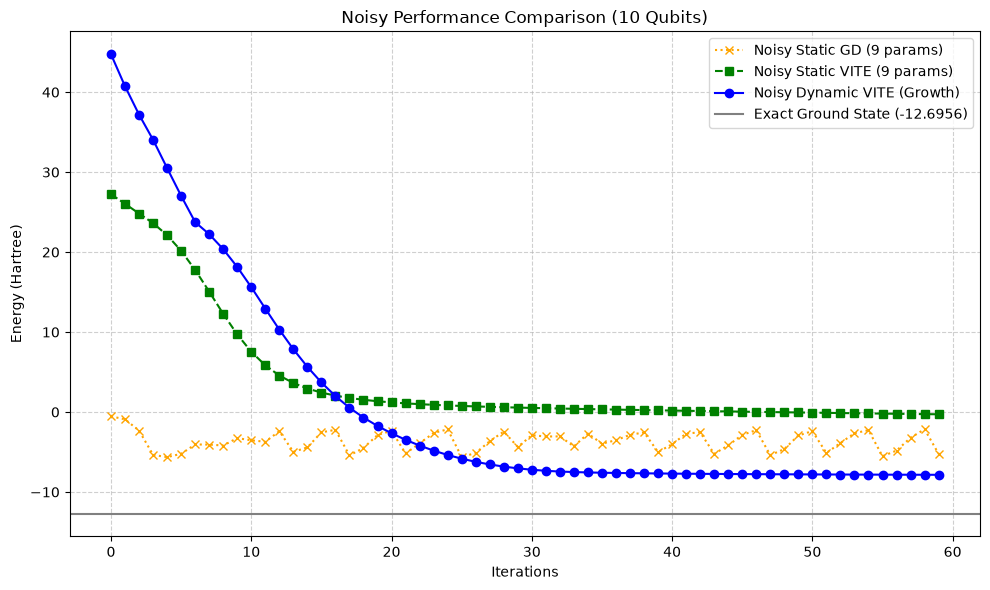

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, DensityMatrix
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

nqubits = 10  
J_coupling = 1.0
h_field = 1.0

noise_model = NoiseModel()
error_1q = depolarizing_error(0.001, 1)
error_2q = depolarizing_error(0.01, 2)
noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'ry', 'rz'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

noisy_sim = AerSimulator(method='density_matrix', noise_model=noise_model)

def ising_hamiltonian(n, J, h):
    paulis, coeffs = [], []
    for i in range(n):
        for j in range(i+1, n):
            label = ["I"] * n
            label[i], label[j] = "Z", "Z"
            paulis.append("".join(label))
            coeffs.append(J)
    for i in range(n):
        label = ["I"] * n
        label[i] = "X"
        paulis.append("".join(label))
        coeffs.append(h)
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))

Hamiltonian = ising_hamiltonian(nqubits, J_coupling, h_field)
exact_ground_energy = eigh(Hamiltonian.to_matrix(), eigvals_only=True)[0]

print(f"System Size: {nqubits} Qubits")
print(f"Exact Ground Energy: {exact_ground_energy:.4f} Hartree\n")

def build_ansatz(params, ops_list):
    qc = QuantumCircuit(nqubits)
    for op_str, param in zip(ops_list, params):
        op = SparsePauliOp(op_str)
        if len(op_str) == 1:
            for q in range(nqubits):
                qc.append(PauliEvolutionGate(op, time=param), [q])
        else:
            for q in range(nqubits - 1):
                qc.append(PauliEvolutionGate(op, time=param), [q, q+1])
    return qc

def get_noisy_energy(params, ops_list, H):
    qc = build_ansatz(params, ops_list)
    qc_t = transpile(qc, basis_gates=['rx', 'ry', 'rz', 'cx'], optimization_level=0)
    qc_t.save_density_matrix()
    result = noisy_sim.run(qc_t).result()
    rho = result.data()['density_matrix']
    return np.real(np.trace(rho.data @ H.to_matrix()))

def get_noisy_V(params, ops_list, H, epsilon=1e-4):
    V = np.zeros(len(params))
    for i in range(len(params)):
        p_plus, p_minus = np.copy(params), np.copy(params)
        p_plus[i] += epsilon
        p_minus[i] -= epsilon
        V[i] = -(get_noisy_energy(p_plus, ops_list, H) - get_noisy_energy(p_minus, ops_list, H)) / (2 * epsilon)
    return V

def get_M_ideal(params, ops_list, epsilon=1e-4):
    sv_center = DensityMatrix(build_ansatz(params, ops_list)).data
    derivatives = []
    for i in range(len(params)):
        p_plus, p_minus = np.copy(params), np.copy(params)
        p_plus[i] += epsilon
        p_minus[i] -= epsilon
        rho_plus = DensityMatrix(build_ansatz(p_plus, ops_list)).data
        rho_minus = DensityMatrix(build_ansatz(p_minus, ops_list)).data
        derivatives.append((rho_plus - rho_minus) / (2 * epsilon))
        
    num_p = len(params)
    M = np.zeros((num_p, num_p))
    for i in range(num_p):
        for j in range(num_p):
            term1 = np.trace(derivatives[i] @ derivatives[j])
            term2 = np.trace(derivatives[i] @ sv_center) * np.trace(sv_center @ derivatives[j])
            M[i, j] = 2 * np.real(term1 + term2)
    return M

def get_noisy_residual(params, ops_list, H, M, V):
    e_val = get_noisy_energy(params, ops_list, H)
    H_sq = (H @ H).simplify()
    e_sq_val = get_noisy_energy(params, ops_list, H_sq)
    var_H = e_sq_val - e_val**2 
    M_reg = M + 0.05 * np.eye(len(params))
    M_inv = np.linalg.pinv(M_reg)
    residual = 2 * var_H - V.T @ M_inv @ V
    return residual

FIXED_OPS = ["X", "Y", "Z", "XX", "YY", "ZZ", "XY", "YX", "XZ"]

def static_gd_noisy_training(H, max_iters=50, learning_rate=0.03):
    current_params = np.random.uniform(-0.1, 0.1, len(FIXED_OPS))
    energy_history = []
    print("Run Noisy Static GD")
    for iteration in range(max_iters):
        V = get_noisy_V(current_params, FIXED_OPS, H)
        current_params = current_params + learning_rate * V
        current_energy = get_noisy_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
    return energy_history

def static_vite_noisy_training(H, max_iters=50, learning_rate=0.03):
    current_params = np.random.uniform(-0.1, 0.1, len(FIXED_OPS))
    energy_history = []
    print("Run Noisy Static VITE")
    for iteration in range(max_iters):
        M = get_M_ideal(current_params, FIXED_OPS)
        V = get_noisy_V(current_params, FIXED_OPS, H)
        M_reg = M + 0.05 * np.eye(len(FIXED_OPS))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        current_params = current_params + learning_rate * d_theta
        current_energy = get_noisy_energy(current_params, FIXED_OPS, H)
        energy_history.append(current_energy)
    return energy_history

def dynamic_vite_noisy_training(H, exact_energy, max_iters=50, learning_rate=0.03, threshold=0.15):
    """實驗組：動態生長 VITE (修正含噪生長邏輯與追蹤)"""
    CANDIDATE_OPS = ["XX", "YY", "ZZ", "XY", "YX", "XZ"]
    Ops = ["X", "Y", "Z"]
    current_params = np.random.uniform(-0.01, 0.01, len(Ops))
    
    energy_history = []
    
    print("開始執行實驗組：含噪動態生長 VITE (From 3 Params)")
    for iteration in range(max_iters):
        M = get_M_ideal(current_params, Ops)
        V = get_noisy_V(current_params, Ops, H)
        
        M_reg = M + 0.05 * np.eye(len(Ops))
        M_inv = np.linalg.pinv(M_reg)
        d_theta = M_inv @ V
        
        current_energy = get_noisy_energy(current_params, Ops, H)
        residual = get_noisy_residual(current_params, Ops, H, M, V)
        energy_history.append(current_energy)
        
        print(f"  [Iter {iteration+1:02d}] 參數: {len(Ops):02d} | 能量: {current_energy:.4f} | 殘差: {residual:.4f}")
        
        # 修正：先進行參數更新，確保每次迭代都有往前走
        current_params = current_params + learning_rate * d_theta
        
        # 修正：再進行殘差觸發判斷 (降低閾值適應雜訊)
        if residual > threshold and len(CANDIDATE_OPS) > 0 and (current_energy - exact_energy) > 0.15:
            new_op = CANDIDATE_OPS.pop(0)
            Ops.append(new_op)
            # 新參數初始化為 0，維持當前演化態
            current_params = np.append(current_params, 0.0)
            print(f"    >>> 觸發動態生長: 已加入量子閘 {new_op}")
            
    print(f"動態 VITE 最終參數數量: {len(Ops)}\n")
    return energy_history

iters = 60
gd_noisy_energies = static_gd_noisy_training(Hamiltonian, max_iters=iters)
svite_noisy_energies = static_vite_noisy_training(Hamiltonian, max_iters=iters)
dvite_noisy_energies = dynamic_vite_noisy_training(Hamiltonian, exact_ground_energy, max_iters=iters)

plt.figure(figsize=(10, 6))
plt.plot(gd_noisy_energies, marker='x', linestyle=':', color='orange', label='Noisy Static GD (9 params)')
plt.plot(svite_noisy_energies, marker='s', linestyle='--', color='green', label='Noisy Static VITE (9 params)')
plt.plot(dvite_noisy_energies, marker='o', linestyle='-', color='blue', label='Noisy Dynamic VITE (Growth)')
plt.axhline(y=exact_ground_energy, color='gray', linestyle='-', label=f'Exact Ground State ({exact_ground_energy:.4f})')
plt.ylabel('Energy (Hartree)')
plt.xlabel('Iterations')
plt.title(f'Noisy Performance Comparison ({nqubits} Qubits)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(desktop/'vite_simulation_5.svg', bbox_inches='tight')
plt.show()